In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

print(con.columns)
print(atu.columns)

Index(['pointid', 'grid_code'], dtype='object')
Index(['pointid', 'grid_code'], dtype='object')


I imported these libraries for data processing, mathmatical operations and visualizations. I then imported ArcNLET data from ArcGIS plume rastors.

In [13]:
con_vals = con["grid_code"]
atu_vals = atu["grid_code"]

print(con_vals.describe())
print(atu_vals.describe())

count    138449.000000
mean          2.733536
std          11.497100
min           0.000001
25%           0.000008
50%           0.000781
75%           0.069205
max         144.000000
Name: grid_code, dtype: float64
count    172828.000000
mean          0.270042
std           1.104746
min           0.000001
25%           0.000004
50%           0.000302
75%           0.012255
max          14.400000
Name: grid_code, dtype: float64


I used the describe function to generate summary statistics, including the mean, median, and range of concentrations for both scenarios

In [16]:
# Removed insignificant extremely low values to better interpret results 
con_vals = con_vals[con_vals > 0.1]
atu_vals = atu_vals[atu_vals > 0.1]

print(len(con_vals), len(atu_vals))

32052 25352


In [18]:
con_above_10 = np.mean(con_vals > 10) * 100
atu_above_10 = np.mean(atu_vals > 10) * 100

print(con_above_10, atu_above_10)

25.85174092100337 0.46150205112022724


In [19]:
# Load data
con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Filter plume cells
threshold = 0.1
con_vals = con_vals[con_vals > threshold]
atu_vals = atu_vals[atu_vals > threshold]

dw_standard = 10.0

def get_stats(values):
    return {
        "n": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "p90": np.percentile(values, 90),
        "max": np.max(values),
        "above_10": 100 * np.mean(values > dw_standard)
    }

con_stats = get_stats(con_vals)
atu_stats = get_stats(atu_vals)

summary_text = (
    f"Conventional\n"
    f"n = {con_stats['n']:,}\n"
    f"Mean = {con_stats['mean']:.2f} mg/L\n"
    f"Median = {con_stats['median']:.2f} mg/L\n"
    f"P90 = {con_stats['p90']:.2f} mg/L\n"
    f"Max = {con_stats['max']:.2f} mg/L\n"
    f">10 mg/L = {con_stats['above_10']:.1f}%\n\n"
    f"ATU\n"
    f"n = {atu_stats['n']:,}\n"
    f"Mean = {atu_stats['mean']:.2f} mg/L\n"
    f"Median = {atu_stats['median']:.2f} mg/L\n"
    f"P90 = {atu_stats['p90']:.2f} mg/L\n"
    f"Max = {atu_stats['max']:.2f} mg/L\n"
    f">10 mg/L = {atu_stats['above_10']:.1f}%"
)

print(summary_text)

Conventional
n = 32,052
Mean = 11.79 mg/L
Median = 1.70 mg/L
P90 = 45.21 mg/L
Max = 144.00 mg/L
>10 mg/L = 25.9%

ATU
n = 25,352
Mean = 1.81 mg/L
Median = 0.68 mg/L
P90 = 7.17 mg/L
Max = 14.40 mg/L
>10 mg/L = 0.5%


This took all the above cells and generated a statistical analysis between the two scenarios. The code was generated with the assistance of LLM ChatGPT 

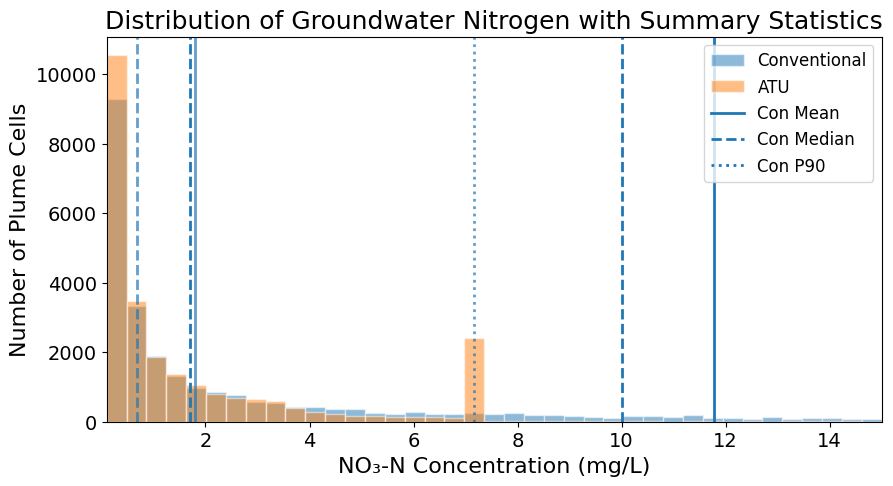

In [28]:
import matplotlib.pyplot as plt

con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Filter plume cells
threshold = 0.1
con_vals = con_vals[con_vals > threshold]
atu_vals = atu_vals[atu_vals > threshold]


# Calculate stats

def get_stats(values):
    return {
        "mean": np.mean(values),
        "median": np.median(values),
        "p90": np.percentile(values, 90)
    }

con_stats = get_stats(con_vals)
atu_stats = get_stats(atu_vals)


# Plot

plt.figure(figsize=(10,5))

bins = np.linspace(0.1, 15, 40)

# Histograms
plt.hist(con_vals, bins=bins, alpha=0.5, label="Conventional", edgecolor="white")
plt.hist(atu_vals, bins=bins, alpha=0.5, label="ATU", edgecolor="white")


# Add stat lines (Conventional)

plt.axvline(con_stats["mean"], linestyle='-', linewidth=2, label="Con Mean")
plt.axvline(con_stats["median"], linestyle='--', linewidth=2, label="Con Median")
plt.axvline(con_stats["p90"], linestyle=':', linewidth=2, label="Con P90")

# Add stat lines (ATU)

plt.axvline(atu_stats["mean"], linestyle='-', linewidth=2, alpha=0.7)
plt.axvline(atu_stats["median"], linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(atu_stats["p90"], linestyle=':', linewidth=2, alpha=0.7)

# Drinking water standard
plt.axvline(x=10, linestyle='--', linewidth=2)

# Labels
plt.xlabel("NO₃-N Concentration (mg/L)", fontsize=16)
plt.ylabel("Number of Plume Cells", fontsize=16)
plt.title("Distribution of Groundwater Nitrogen with Summary Statistics", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=12)

plt.xlim(0.1, 15)

# Save
plt.savefig(r"C:\ArcNLET\data\Histogram_with_Stats.png",
            dpi=300, bbox_inches='tight')

plt.show()

Saved to: C:\ArcNLET\data\CDF_Nitrogen_Clean_BIG.png


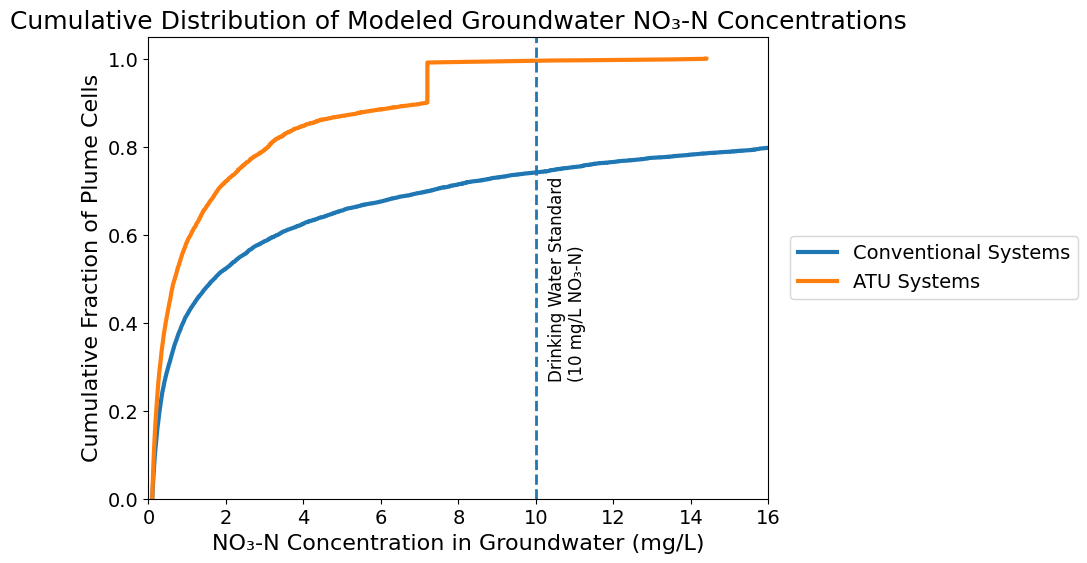

In [27]:
con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

# Extract values
con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Filter plume values
con_vals = con_vals[con_vals > 0.1]
atu_vals = atu_vals[atu_vals > 0.1]

# Sort
con_sorted = np.sort(con_vals)
atu_sorted = np.sort(atu_vals)

# CDF
con_cdf = np.arange(1, len(con_sorted)+1) / len(con_sorted)
atu_cdf = np.arange(1, len(atu_sorted)+1) / len(atu_sorted)


plt.figure(figsize=(8,6))

# Thicker lines for visibility
plt.plot(con_sorted, con_cdf, label="Conventional Systems", linewidth=3)
plt.plot(atu_sorted, atu_cdf, label="ATU Systems", linewidth=3)

# Labels
plt.xlabel("NO₃-N Concentration in Groundwater (mg/L)", fontsize=16)
plt.ylabel("Cumulative Fraction of Plume Cells", fontsize=16)

# Title 
plt.title(
    "Cumulative Distribution of Modeled Groundwater NO₃-N Concentrations",
    fontsize=18
)

# Drinking water standard
plt.axvline(x=10, linestyle='--', linewidth=2)

plt.text(
    10.3, 0.5,
    "Drinking Water Standard\n(10 mg/L NO₃-N)",
    rotation=90,
    verticalalignment='center',
    fontsize=12
)

# Remove the grid
plt.grid(False)

# axes
plt.xlim(0, 16)
plt.ylim(0, 1.05)

# ticks
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16], fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)

# Legend
plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1.02, 0.5))


save_path = r"C:\ArcNLET\data\CDF_Nitrogen_Clean_BIG.png"

plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Saved to: {save_path}")

plt.show()

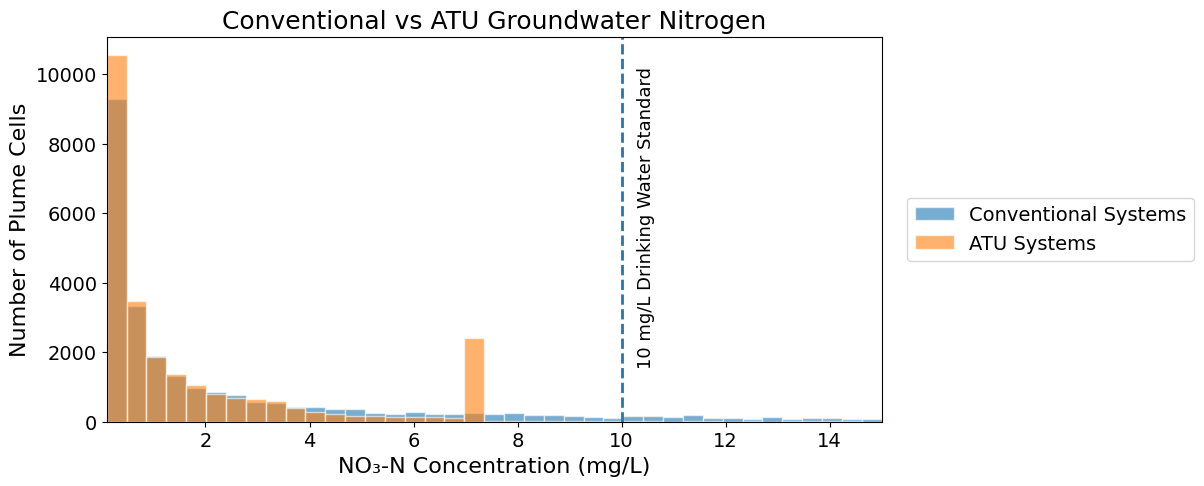

In [26]:
con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Filter plume cells
con_vals = con_vals[con_vals > 0.1]
atu_vals = atu_vals[atu_vals > 0.1]

# -----------------------------
# Create figure
# -----------------------------
plt.figure(figsize=(10,5))

# Bins aligned with data
bins = np.linspace(min(con_vals.min(), atu_vals.min()), 15, 40)

# Histogram
plt.hist(con_vals, bins=bins, alpha=0.6,
         label="Conventional Systems", edgecolor="white")
plt.hist(atu_vals, bins=bins, alpha=0.6,
         label="ATU Systems", edgecolor="white")

# axis
plt.xlim(0.1, 15)


# Drinking water standard

plt.axvline(x=10, linestyle='--', linewidth=2)

plt.text(
    10.3,
    plt.ylim()[1]*0.15,
    "10 mg/L Drinking Water Standard",
    rotation=90,
    fontsize=13
)

# Labels 

plt.xlabel("NO₃-N Concentration (mg/L)", fontsize=16)
plt.ylabel("Number of Plume Cells", fontsize=16)

plt.title(
    "Conventional vs ATU Groundwater Nitrogen",
    fontsize=18
)

# ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1.02, 0.5))


# Save
plt.savefig(r"C:\ArcNLET\data\Scenario_Design_Figure_BIG.png",
            dpi=300, bbox_inches='tight')

plt.show()

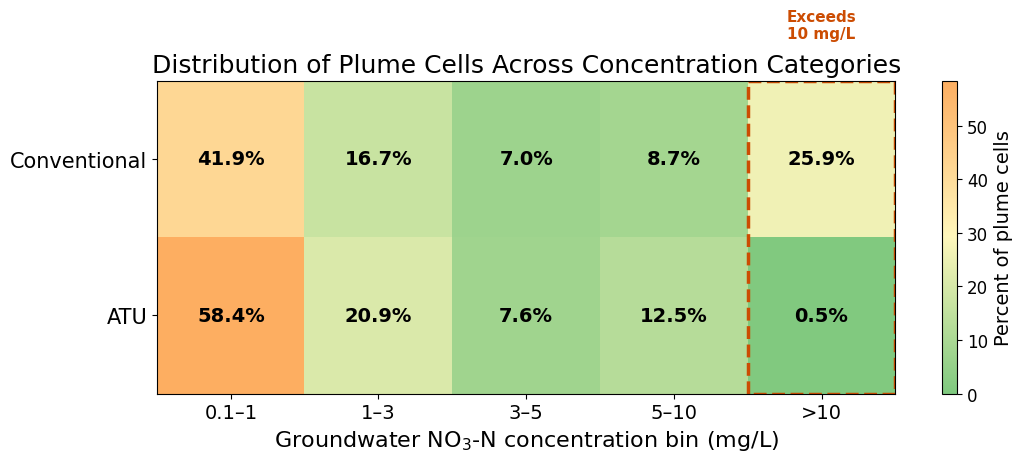

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Keep meaningful plume cells only
con_vals = con_vals[con_vals > 0.1]
atu_vals = atu_vals[atu_vals > 0.1]

# -----------------------------
# Define concentration bins
# -----------------------------
bins = [0.1, 1, 3, 5, 10, np.inf]
bin_labels = ["0.1–1", "1–3", "3–5", "5–10", ">10"]

# -----------------------------
# Calculate % of plume cells
# -----------------------------
con_counts, _ = np.histogram(con_vals, bins=bins)
atu_counts, _ = np.histogram(atu_vals, bins=bins)

con_pct = con_counts / con_counts.sum() * 100
atu_pct = atu_counts / atu_counts.sum() * 100

heatmap_data = np.vstack([con_pct, atu_pct])

# -----------------------------
# Custom ArcGIS-like color ramp
# green → light yellow → soft orange
# -----------------------------
arcgis_like = LinearSegmentedColormap.from_list(
    "arcgis_like",
    ["#7fc97f", "#fff7bc", "#fdae61"]
)

# -----------------------------
# Plot heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 4.8))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap=arcgis_like,
    vmin=0,
    vmax=np.max(heatmap_data)
)

# Axis labels
ax.set_xticks(np.arange(len(bin_labels)))
ax.set_xticklabels(bin_labels, fontsize=14)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Conventional", "ATU"], fontsize=15)

ax.set_xlabel("Groundwater NO$_3$-N concentration bin (mg/L)", fontsize=16)
ax.set_title(
    "Distribution of Plume Cells Across Concentration Categories",
    fontsize=18
)

# -----------------------------
# Annotate cells
# -----------------------------
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        ax.text(
            j, i,
            f"{value:.1f}%",
            ha="center", va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

# -----------------------------
# Subtly highlight >10 mg/L column
# -----------------------------
highlight_col = 4  # index of >10 column

rect = Rectangle(
    (highlight_col - 0.5, -0.5),   # bottom-left corner
    1,                             # width of one column
    2,                             # spans both rows
    fill=False,
    edgecolor="#cc4c02",
    linewidth=2.5,
    linestyle="--"
)
ax.add_patch(rect)

# Optional label above highlighted column
ax.text(
    highlight_col, -0.75,
    "Exceeds\n10 mg/L",
    ha="center", va="bottom",
    fontsize=11,
    color="#cc4c02",
    fontweight="bold"
)

# -----------------------------
# Colorbar
# -----------------------------
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of plume cells", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Clean layout
plt.tight_layout()

# Save
plt.savefig(
    r"C:\ArcNLET\data\Heatmap_Summary_Custom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

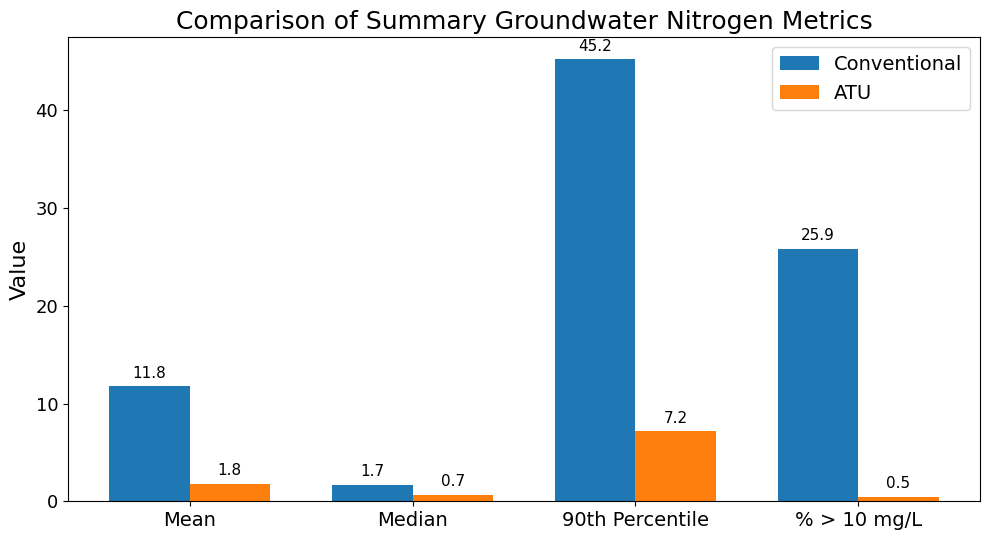

In [25]:
con = pd.read_csv(r"C:\ArcNLET\data\con_points_fixed.csv")
atu = pd.read_csv(r"C:\ArcNLET\data\atu_points_fixed.csv")

con_vals = con["grid_code"].astype(float)
atu_vals = atu["grid_code"].astype(float)

# Keep meaningful plume cells only
threshold = 0.1
con_vals = con_vals[con_vals > threshold]
atu_vals = atu_vals[atu_vals > threshold]

dw_standard = 10.0

# -----------------------------
# Summary stats
# -----------------------------
def get_stats(values):
    return {
        "Mean": np.mean(values),
        "Median": np.median(values),
        "90th Percentile": np.percentile(values, 90),
        "% > 10 mg/L": 100 * np.mean(values > dw_standard)
    }

con_stats = get_stats(con_vals)
atu_stats = get_stats(atu_vals)

metrics = list(con_stats.keys())
con_data = [con_stats[m] for m in metrics]
atu_data = [atu_stats[m] for m in metrics]

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))

bars1 = ax.bar(x - width/2, con_data, width, label="Conventional")
bars2 = ax.bar(x + width/2, atu_data, width, label="ATU")

# Labels
ax.set_ylabel("Value", fontsize=16)
ax.set_title("Comparison of Summary Groundwater Nitrogen Metrics", fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)
ax.tick_params(axis='y', labelsize=13)

# Legend
ax.legend(fontsize=14)

# Annotate bars
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11
        )

label_bars(bars1)
label_bars(bars2)

plt.tight_layout()
plt.savefig(r"C:\ArcNLET\data\Summary_Metrics_BarChart.png", dpi=300, bbox_inches="tight")
plt.show()

The above coding for the figures were generated with assistance from LLM ChatGPT.All extracted data values were derived from ArcNLET modeling by the author of the study.